In [1]:
# ============================================================
# Airline Route Demand Prediction
# Applied Data Science Project
# Section 1 - Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [2]:
# ============================================================
# Section 2 - Load the Dataset
# ============================================================

file_path = "../data/North_America_Schedules.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Display the first five rows
df.head()

,Airport Market,Origin Airport,Origin Airport Name,Origin City Name,Origin Country Name,Destination Airport,Destination Airport Name,Destination City Name,Destination Country Name,Operating Airline,...,Fleet,Manufacturer,Schedule Type,DepCount,Operating Airline Capacity,Operating Airline ASK (Millions),Seats per Operation,Distance (km),Distance (nm),Distance Category (NM)
0,LGA-ATL,LGA,LAGUARDIA AIRPORT,NEW YORK,UNITED STATES,ATL,HARTSFIELD-JACKSON INTERNATIONAL AIRPORT,ATLANTA,UNITED STATES,DL,...,321,AIRBUS,AIR,419,80029,99.08,191,1238.0,668.47,500-1000
1,LGA-ATL,ATL,HARTSFIELD-JACKSON INTERNATIONAL AIRPORT,ATLANTA,UNITED STATES,LGA,LAGUARDIA AIRPORT,NEW YORK,UNITED STATES,DL,...,321,AIRBUS,AIR,417,79647,98.60,191,1238.0,668.47,500-1000
2,ORD-LGA,LGA,LAGUARDIA AIRPORT,NEW YORK,UNITED STATES,ORD,O'HARE INTERNATIONAL AIRPORT,CHICAGO,UNITED STATES,UA,...,738,BOEING,AIR,397,65902,77.63,166,1178.0,636.07,500-1000
3,ORD-LGA,ORD,O'HARE INTERNATIONAL AIRPORT,CHICAGO,UNITED STATES,LGA,LAGUARDIA AIRPORT,NEW YORK,UNITED STATES,UA,...,738,BOEING,AIR,396,65736,77.44,166,1178.0,636.07,500-1000
4,OGG-HNL,OGG,KAHULUI AIRPORT,KAHULUI,UNITED STATES,HNL,HONOLULU INTERNATIONAL AIRPORT,HONOLULU,UNITED STATES,AS,...,717,BOEING,AIR,483,61824,9.40,128,152.0,82.07,0-500


In [4]:
# ============================================================
# Section 3 - Explore the Dataset
# ============================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n")

print("=" * 60)
print("Column Names")
print("=" * 60)
print(df.columns.tolist())

print("\n")

print("=" * 60)
print("Data Types")
print("=" * 60)
print(df.dtypes)

print("\n")

print("=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

print("\n")

print("=" * 60)
print("Summary Statistics")
print("=" * 60)
print(df.describe())

Dataset Shape
(251018, 24)


Column Names
['Airport Market', 'Origin Airport', 'Origin Airport Name', 'Origin City Name', 'Origin Country Name', 'Destination Airport', 'Destination Airport Name', 'Destination City Name', 'Destination Country Name', 'Operating Airline', 'Operating Airline Name', 'Code Share', 'Year', 'Month', 'Fleet', 'Manufacturer', 'Schedule Type', 'DepCount', 'Operating Airline   Capacity', 'Operating Airline   ASK (Millions)', 'Seats per Operation', 'Distance (km)', 'Distance (nm)', 'Distance Category (NM)']


Data Types
Airport Market                         object
Origin Airport                         object
Origin Airport Name                    object
Origin City Name                       object
Origin Country Name                    object
Destination Airport                    object
Destination Airport Name               object
Destination City Name                  object
Destination Country Name               object
Operating Airline                      

In [5]:
# ============================================================
# Section 4 - Data Cleaning
# ============================================================

print("=" * 60)
print("Duplicate Rows")
print("=" * 60)

duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

print("\n")

print("=" * 60)
print("Missing Value Percentage")
print("=" * 60)

missing = (df.isnull().sum() / len(df)) * 100

print(missing[missing > 0].sort_values(ascending=False))

print("\n")

print("=" * 60)
print("Unique Airlines")
print("=" * 60)

print(df["Operating Airline"].nunique())

print("\n")

print("=" * 60)
print("Unique Fleets")
print("=" * 60)

print(df["Fleet"].nunique())

print("\n")

print("=" * 60)
print("Unique Airport Markets")
print("=" * 60)

print(df["Airport Market"].nunique())

Duplicate Rows
Duplicate rows: 0


Missing Value Percentage
Operating Airline   ASK (Millions)    0.092424
Distance (km)                         0.092424
dtype: float64


Unique Airlines
99


Unique Fleets
96


Unique Airport Markets
5694


In [6]:
# ============================================================
# Section 5 - Create the Modeling Dataset
# ============================================================

# Remove rows with missing values
df = df.dropna()

# Remove columns that will not be used
df_model = df.drop(columns=[
    "Operating Airline   Capacity",
    "Operating Airline   ASK (Millions)",
    "Distance (km)"
])

print("Modeling dataset created successfully.")

print("\nDataset Shape:")
print(df_model.shape)

print("\nColumns:")
print(df_model.columns.tolist())

Modeling dataset created successfully.

Dataset Shape:
(250786, 21)

Columns:
['Airport Market', 'Origin Airport', 'Origin Airport Name', 'Origin City Name', 'Origin Country Name', 'Destination Airport', 'Destination Airport Name', 'Destination City Name', 'Destination Country Name', 'Operating Airline', 'Operating Airline Name', 'Code Share', 'Year', 'Month', 'Fleet', 'Manufacturer', 'Schedule Type', 'DepCount', 'Seats per Operation', 'Distance (nm)', 'Distance Category (NM)']


In [7]:
# ============================================================
# Section 6 - Basic Dataset Information
# ============================================================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 250786 entries, 0 to 251017
Data columns (total 24 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Airport Market                      250786 non-null  object 
 1   Origin Airport                      250786 non-null  object 
 2   Origin Airport Name                 250786 non-null  object 
 3   Origin City Name                    250786 non-null  object 
 4   Origin Country Name                 250786 non-null  object 
 5   Destination Airport                 250786 non-null  object 
 6   Destination Airport Name            250786 non-null  object 
 7   Destination City Name               250786 non-null  object 
 8   Destination Country Name            250786 non-null  object 
 9   Operating Airline                   250786 non-null  object 
 10  Operating Airline Name              250786 non-null  object 
 11  Code Share                     

In [8]:
# ============================================================
# Numerical Summary
# ============================================================

df.describe()

,Year,Month,DepCount,Operating Airline Capacity,Operating Airline ASK (Millions),Seats per Operation,Distance (km),Distance (nm)
count,250786.000000,250786.000000,250786.000000,250786.000000,250786.000000,250786.000000,250786.000000,250786.000000
mean,2026.317370,6.868474,38.807593,4910.544967,7.290198,134.110804,1375.982415,742.971083
std,0.465454,3.357151,44.297773,6472.134245,12.844598,57.334665,1000.420088,540.183587
min,2026.000000,1.000000,1.000000,5.000000,0.000000,4.000000,7.000000,3.780000
25%,2026.000000,4.000000,10.000000,1140.000000,1.060000,76.000000,647.000000,349.350000
50%,2026.000000,7.000000,29.000000,3090.000000,3.050000,150.000000,1157.000000,624.730000
75%,2027.000000,10.000000,54.000000,5928.000000,7.820000,175.000000,1808.000000,976.240000
max,2027.000000,12.000000,1014.000000,110047.000000,200.960000,440.000000,8201.000000,4428.190000


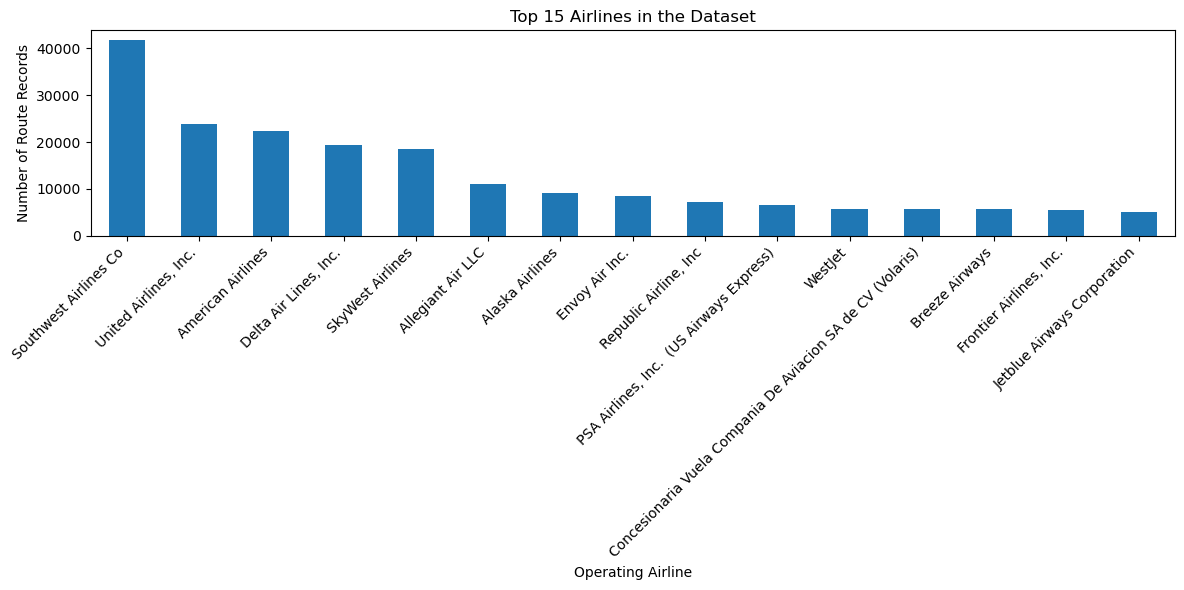

In [9]:
# ============================================================
# Top 15 Airlines by Number of Records
# ============================================================

top_airlines = (
    df["Operating Airline Name"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

top_airlines.plot(kind="bar")

plt.title("Top 15 Airlines in the Dataset")
plt.xlabel("Operating Airline")
plt.ylabel("Number of Route Records")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "../figures/figure_1_top_15_airlines.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

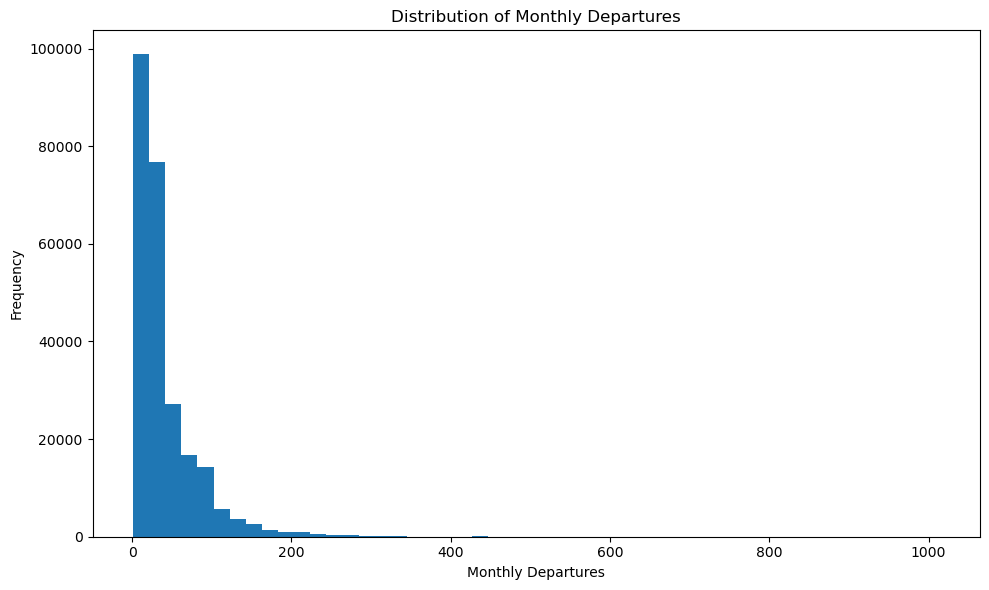

In [10]:
# ============================================================
# Distribution of Monthly Departures
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(df["DepCount"], bins=50)

plt.title("Distribution of Monthly Departures")
plt.xlabel("Monthly Departures")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../figures/figure_2_departure_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

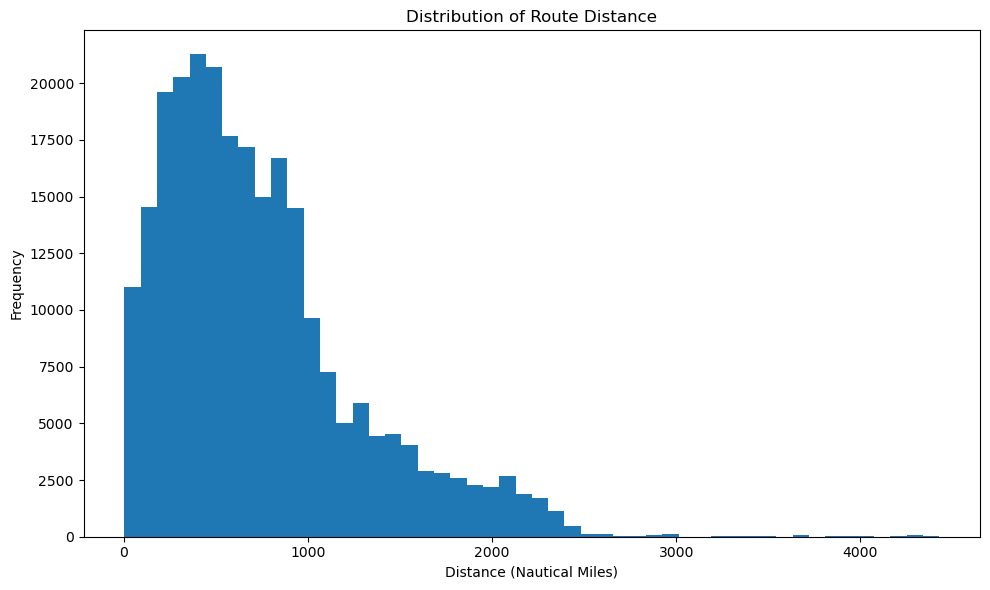

In [11]:
# ============================================================
# Distribution of Route Distance
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(df["Distance (nm)"], bins=50)

plt.title("Distribution of Route Distance")
plt.xlabel("Distance (Nautical Miles)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../figures/figure_3_route_distance_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ============================================================
# Correlation Matrix
# ============================================================

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

correlation

,Year,Month,DepCount,Operating Airline Capacity,Operating Airline ASK (Millions),Seats per Operation,Distance (km),Distance (nm)
Year,1.000000,-0.844214,0.101898,0.076953,0.067807,-0.067202,0.011058,0.011058
Month,-0.844214,1.000000,-0.039495,-0.027054,-0.027981,0.037224,-0.010619,-0.010619
DepCount,0.101898,-0.039495,1.000000,0.839669,0.528173,-0.115743,-0.123997,-0.123997
Operating Airline Capacity,0.076953,-0.027054,0.839669,1.000000,0.757548,0.258578,0.082374,0.082374
Operating Airline ASK (Millions),0.067807,-0.027981,0.528173,0.757548,1.000000,0.348779,0.479027,0.479027
Seats per Operation,-0.067202,0.037224,-0.115743,0.258578,0.348779,1.000000,0.504639,0.504639
Distance (km),0.011058,-0.010619,-0.123997,0.082374,0.479027,0.504639,1.000000,1.000000
Distance (nm),0.011058,-0.010619,-0.123997,0.082374,0.479027,0.504639,1.000000,1.000000


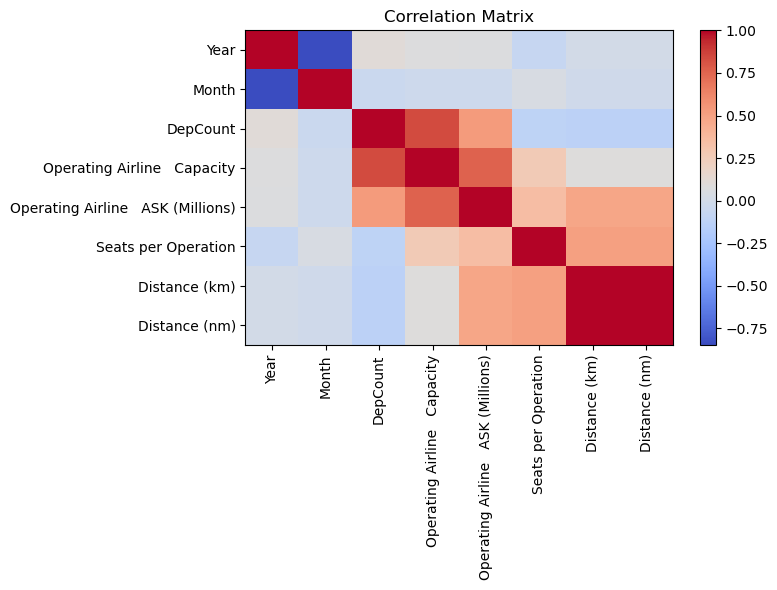

In [13]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../figures/figure_4_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

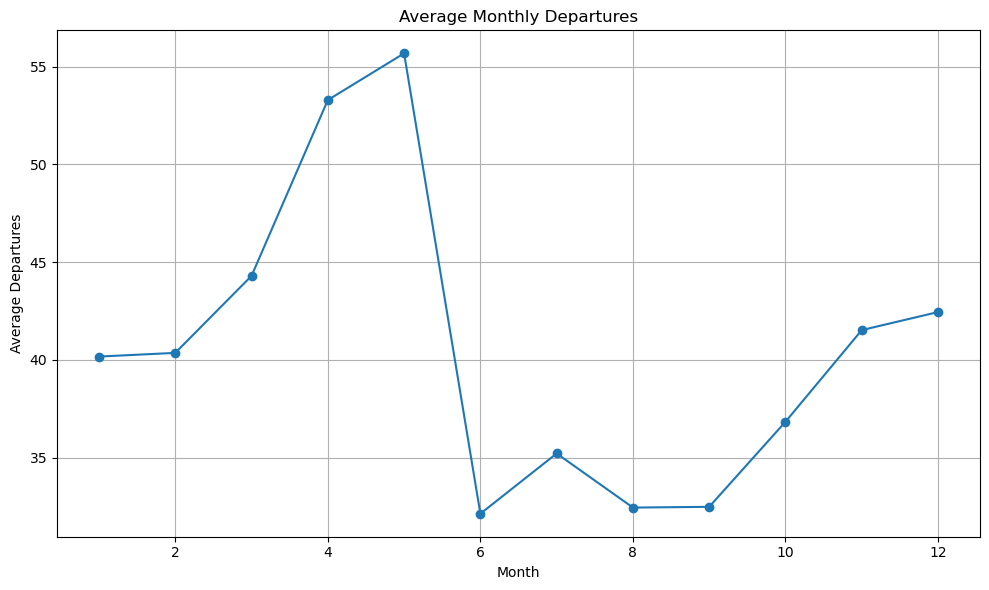

In [14]:
# ============================================================
# Average Monthly Departures by Month
# ============================================================

monthly_departures = df.groupby("Month")["DepCount"].mean()

plt.figure(figsize=(10, 6))

monthly_departures.plot(marker="o")

plt.title("Average Monthly Departures")
plt.xlabel("Month")
plt.ylabel("Average Departures")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/figure_5_average_monthly_departures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

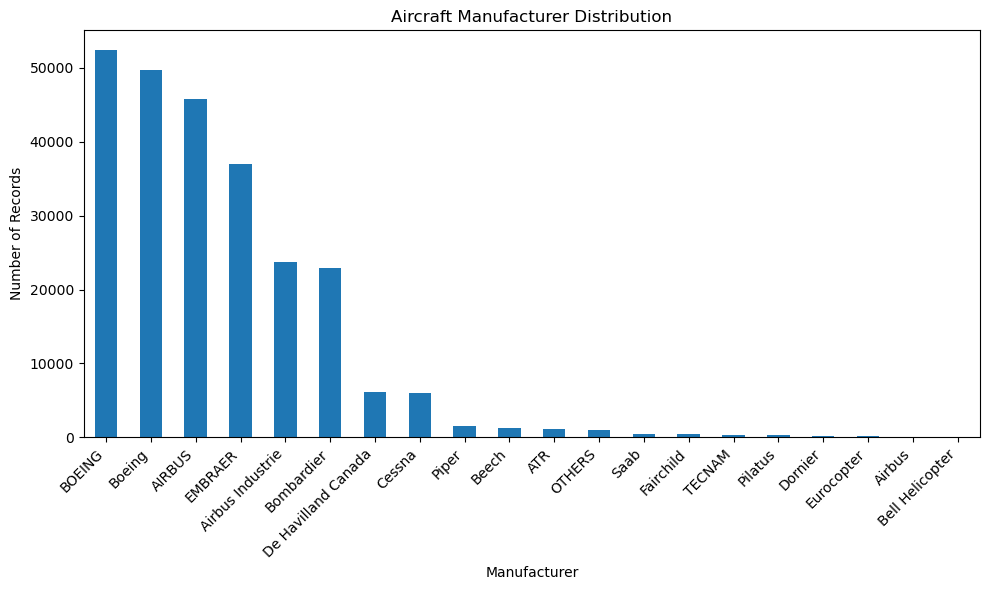

In [15]:
# ============================================================
# Aircraft Manufacturer Distribution
# ============================================================

manufacturer = df["Manufacturer"].value_counts()

plt.figure(figsize=(10, 6))

manufacturer.plot(kind="bar")

plt.title("Aircraft Manufacturer Distribution")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Records")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "../figures/figure_6_manufacturer_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

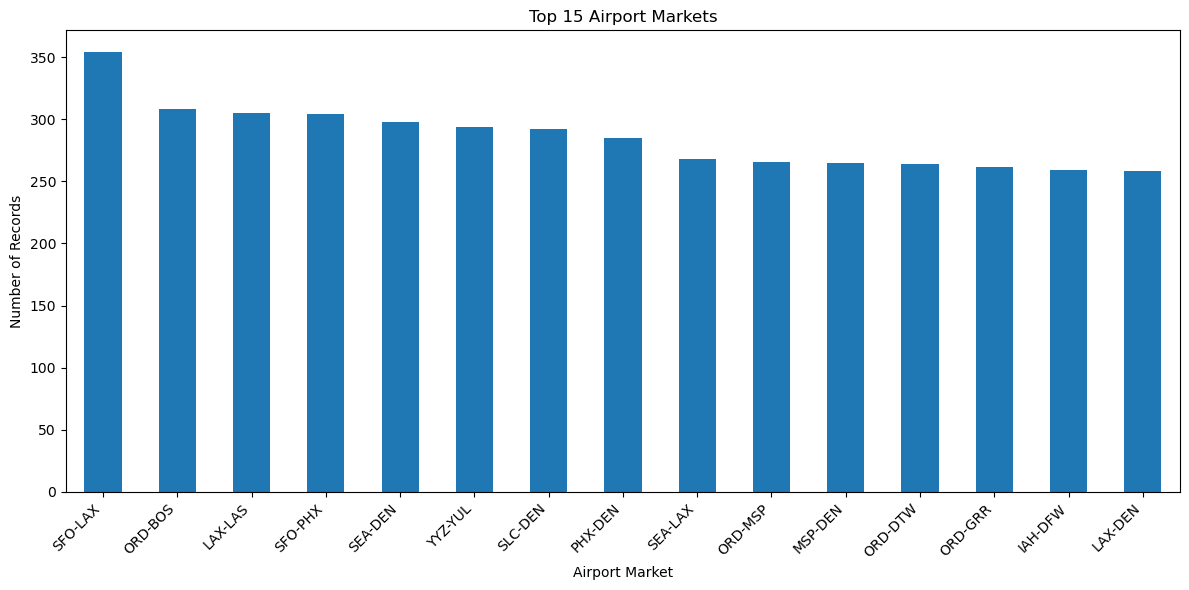

In [16]:
# ============================================================
# Top Airport Markets
# ============================================================

markets = df["Airport Market"].value_counts().head(15)

plt.figure(figsize=(12, 6))

markets.plot(kind="bar")

plt.title("Top 15 Airport Markets")
plt.xlabel("Airport Market")
plt.ylabel("Number of Records")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "../figures/figure_7_top_airport_markets.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# ==========================================================
# Section 8 - Feature Engineering
# ==========================================================

# Create a copy for modeling
model_df = df.copy()

# Remove columns that won't help the prediction
drop_columns = [
    "Airport Market",
    "Origin Airport Name",
    "Destination Airport Name",
    "Operating Airline Name"
]

model_df = model_df.drop(columns=drop_columns)

print("Model dataset shape:")
print(model_df.shape)

model_df.head()

Model dataset shape:
(250786, 20)


,Origin Airport,Origin City Name,Origin Country Name,Destination Airport,Destination City Name,Destination Country Name,Operating Airline,Code Share,Year,Month,Fleet,Manufacturer,Schedule Type,DepCount,Operating Airline Capacity,Operating Airline ASK (Millions),Seats per Operation,Distance (km),Distance (nm),Distance Category (NM)
0,LGA,NEW YORK,UNITED STATES,ATL,ATLANTA,UNITED STATES,DL,NO,2026,6,321,AIRBUS,AIR,419,80029,99.08,191,1238.0,668.47,500-1000
1,ATL,ATLANTA,UNITED STATES,LGA,NEW YORK,UNITED STATES,DL,NO,2026,6,321,AIRBUS,AIR,417,79647,98.60,191,1238.0,668.47,500-1000
2,LGA,NEW YORK,UNITED STATES,ORD,CHICAGO,UNITED STATES,UA,NO,2026,6,738,BOEING,AIR,397,65902,77.63,166,1178.0,636.07,500-1000
3,ORD,CHICAGO,UNITED STATES,LGA,NEW YORK,UNITED STATES,UA,NO,2026,6,738,BOEING,AIR,396,65736,77.44,166,1178.0,636.07,500-1000
4,OGG,KAHULUI,UNITED STATES,HNL,HONOLULU,UNITED STATES,AS,NO,2026,6,717,BOEING,AIR,483,61824,9.40,128,152.0,82.07,0-500


In [18]:
# ==========================================================
# Section 9 - Encode Categorical Variables
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = model_df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    encoder = LabelEncoder()
    model_df[column] = encoder.fit_transform(model_df[column])
    label_encoders[column] = encoder

print("Encoding complete.")

model_df.head()

Encoding complete.


,Origin Airport,Origin City Name,Origin Country Name,Destination Airport,Destination City Name,Destination Country Name,Operating Airline,Code Share,Year,Month,Fleet,Manufacturer,Schedule Type,DepCount,Operating Airline Capacity,Operating Airline ASK (Millions),Seats per Operation,Distance (km),Distance (nm),Distance Category (NM)
0,401,551,4,46,48,4,33,0,2026,6,6,0,0,419,80029,99.08,191,1238.0,668.47,6
1,47,49,4,403,552,4,33,0,2026,6,6,0,0,417,79647,98.60,191,1238.0,668.47,6
2,401,551,4,512,136,4,78,0,2026,6,23,4,0,397,65902,77.63,166,1178.0,636.07,6
3,509,135,4,403,552,4,78,0,2026,6,23,4,0,396,65736,77.44,166,1178.0,636.07,6
4,499,362,4,263,313,4,28,0,2026,6,18,4,0,483,61824,9.40,128,152.0,82.07,0


In [19]:
# ==========================================================
# Section 10 - Define Features and Target
# ==========================================================

X = model_df.drop(columns=["DepCount"])

y = model_df["DepCount"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (250786, 19)
Target shape: (250786,)


In [20]:
# ==========================================================
# Section 11 - Train/Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (200628, 19)
Testing set: (50158, 19)


In [21]:
# ==========================================================
# Section 12 - Linear Regression Model
# ==========================================================

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [22]:
# ==========================================================
# Section 13 - Make Predictions
# ==========================================================

y_pred = linear_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [23]:
# ==========================================================
# Section 14 - Model Evaluation
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-" * 40)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Linear Regression Results
----------------------------------------
MAE : 8.97
MSE : 281.48
RMSE: 16.78
R²  : 0.8545


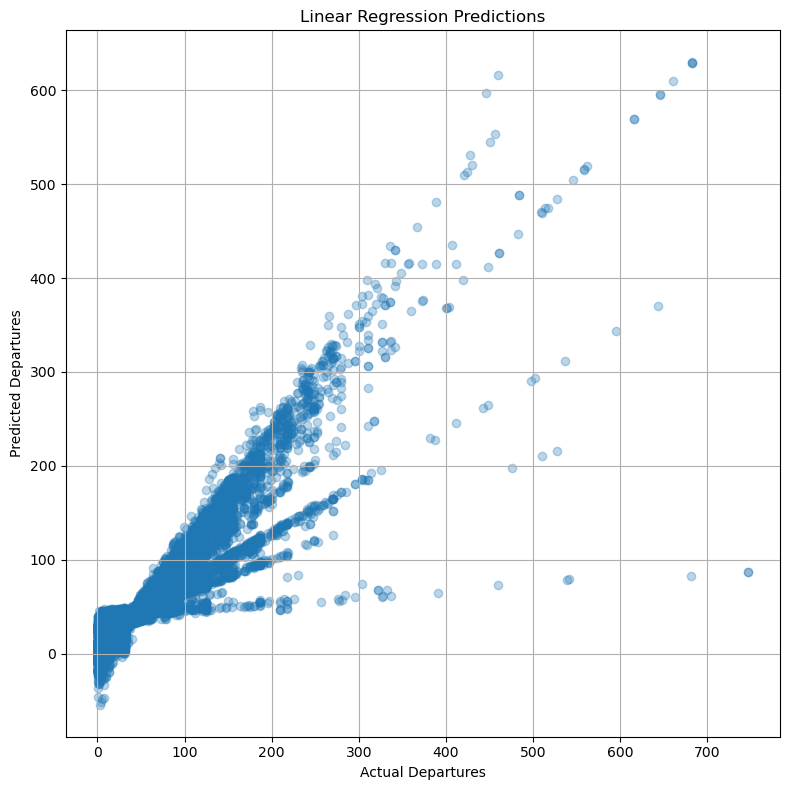

In [24]:
# ============================================================
# Linear Regression: Actual vs. Predicted Departures
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Departures")
plt.ylabel("Predicted Departures")

plt.title("Linear Regression Predictions")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/figure_8_linear_regression_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ==========================================================
# Section 16 - Random Forest Regression
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [26]:
# ==========================================================
# Section 17 - Random Forest Predictions
# ==========================================================

rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed.")

Random Forest predictions completed.


In [27]:
# ==========================================================
# Section 18 - Random Forest Evaluation
# ==========================================================

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("-"*40)

print(f"MAE : {rf_mae:.2f}")
print(f"MSE : {rf_mse:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest Results
----------------------------------------
MAE : 0.05
MSE : 0.37
RMSE: 0.61
R²  : 0.9998


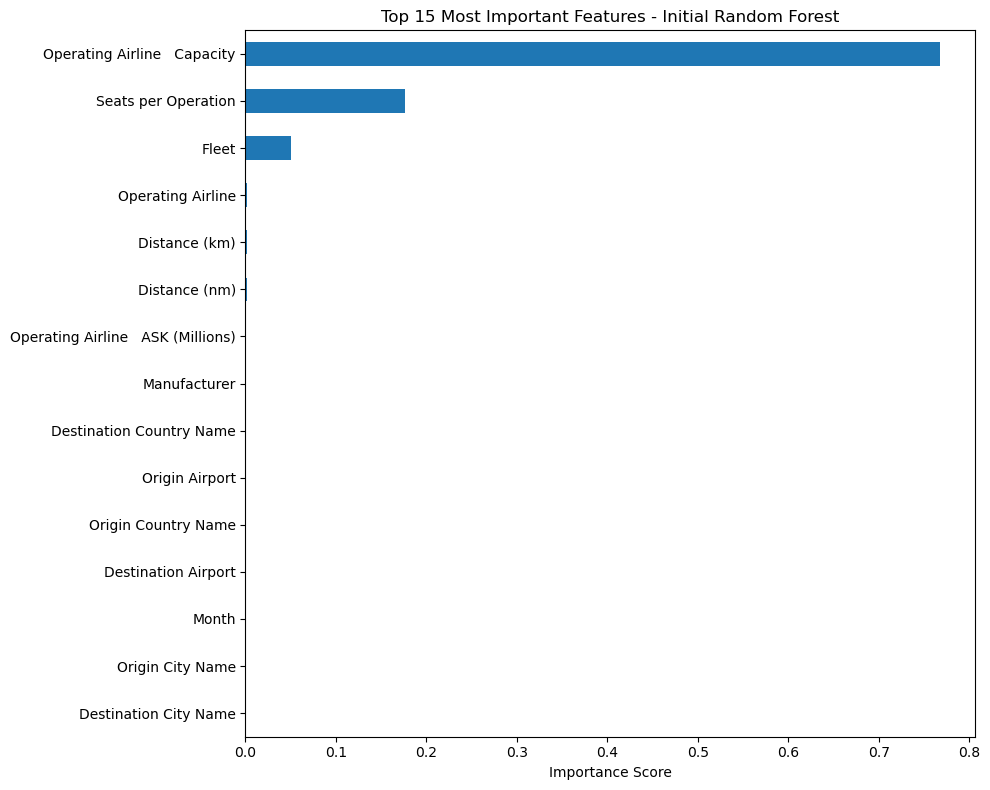

In [28]:
# ============================================================
# Initial Random Forest Feature Importance
# ============================================================

importance = (
    pd.Series(
        rf_model.feature_importances_,
        index=X.columns
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Most Important Features - Initial Random Forest")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../figures/figure_9_initial_rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

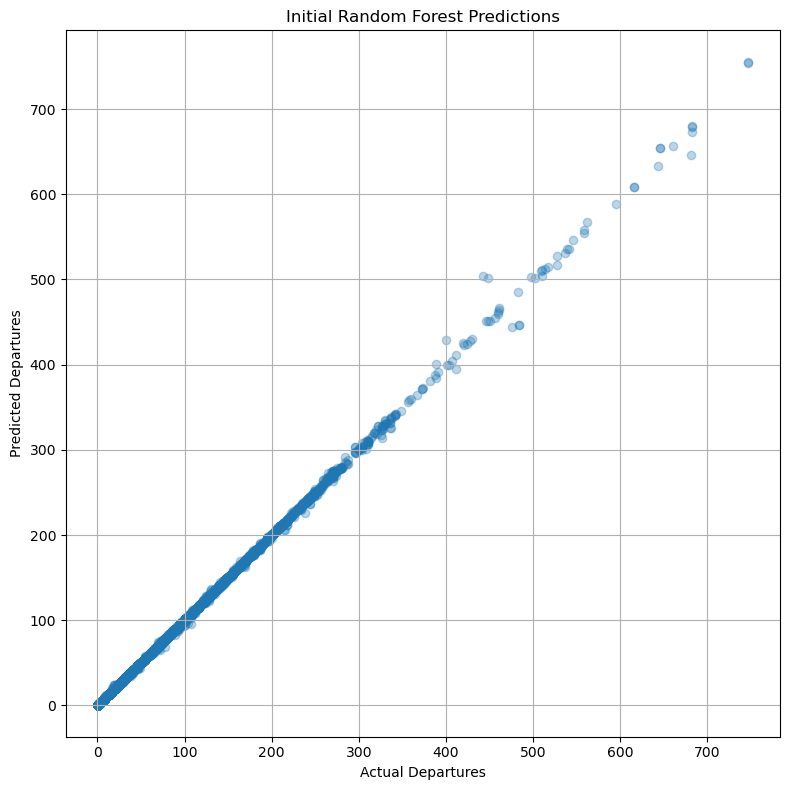

In [29]:
# ============================================================
# Initial Random Forest: Actual vs. Predicted Departures
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.3
)

plt.xlabel("Actual Departures")
plt.ylabel("Predicted Departures")

plt.title("Initial Random Forest Predictions")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/figure_10_initial_rf_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# ==========================================================
# Section 21 - Revised Feature Set Without Leakage Variables
# ==========================================================

# Remove variables that are directly related to DepCount
leakage_columns = [
    "DepCount",
    "Operating Airline   Capacity",
    "Operating Airline   ASK (Millions)"
]

X_revised = model_df.drop(columns=leakage_columns)

y_revised = model_df["DepCount"]

print("Revised features shape:", X_revised.shape)
print("Revised target shape:", y_revised.shape)
print("Revised feature columns:")
print(X_revised.columns.tolist())

Revised features shape: (250786, 17)
Revised target shape: (250786,)
Revised feature columns:
['Origin Airport', 'Origin City Name', 'Origin Country Name', 'Destination Airport', 'Destination City Name', 'Destination Country Name', 'Operating Airline', 'Code Share', 'Year', 'Month', 'Fleet', 'Manufacturer', 'Schedule Type', 'Seats per Operation', 'Distance (km)', 'Distance (nm)', 'Distance Category (NM)']


In [31]:
# ==========================================================
# Section 22 - Revised Train/Test Split
# ==========================================================

X_train_rev, X_test_rev, y_train_rev, y_test_rev = train_test_split(
    X_revised,
    y_revised,
    test_size=0.20,
    random_state=42
)

print("Revised training set:", X_train_rev.shape)
print("Revised testing set:", X_test_rev.shape)

Revised training set: (200628, 17)
Revised testing set: (50158, 17)


In [32]:
# ==========================================================
# Section 23 - Revised Random Forest Model
# ==========================================================

rf_model_revised = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model_revised.fit(X_train_rev, y_train_rev)

print("Revised Random Forest model trained successfully.")

Revised Random Forest model trained successfully.


In [33]:
# ==========================================================
# Section 24 - Revised Random Forest Evaluation
# ==========================================================

rf_pred_revised = rf_model_revised.predict(X_test_rev)

rf_rev_mae = mean_absolute_error(y_test_rev, rf_pred_revised)
rf_rev_mse = mean_squared_error(y_test_rev, rf_pred_revised)
rf_rev_rmse = np.sqrt(rf_rev_mse)
rf_rev_r2 = r2_score(y_test_rev, rf_pred_revised)

print("Revised Random Forest Results")
print("-" * 40)

print(f"MAE : {rf_rev_mae:.2f}")
print(f"MSE : {rf_rev_mse:.2f}")
print(f"RMSE: {rf_rev_rmse:.2f}")
print(f"R²  : {rf_rev_r2:.4f}")

Revised Random Forest Results
----------------------------------------
MAE : 9.71
MSE : 256.31
RMSE: 16.01
R²  : 0.8675


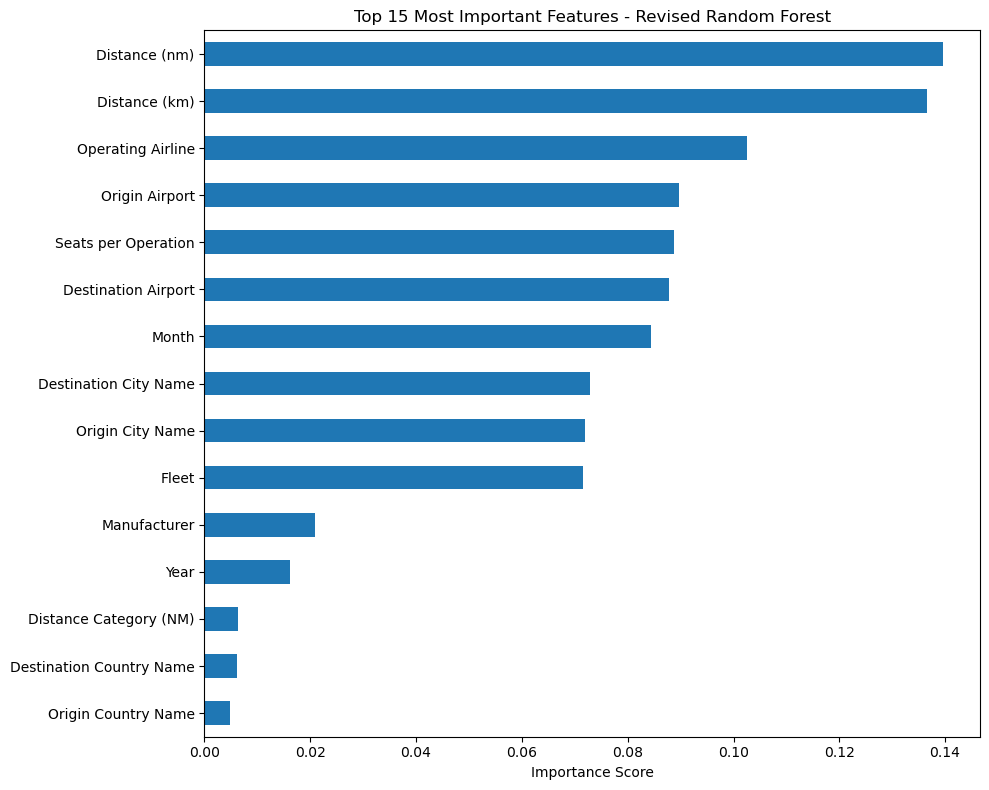

In [34]:
# ============================================================
# Revised Random Forest Feature Importance
# ============================================================

importance_revised = (
    pd.Series(
        rf_model_revised.feature_importances_,
        index=X_revised.columns
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

importance_revised.head(15).plot(kind="barh")

plt.title("Top 15 Most Important Features - Revised Random Forest")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../figures/figure_11_revised_rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

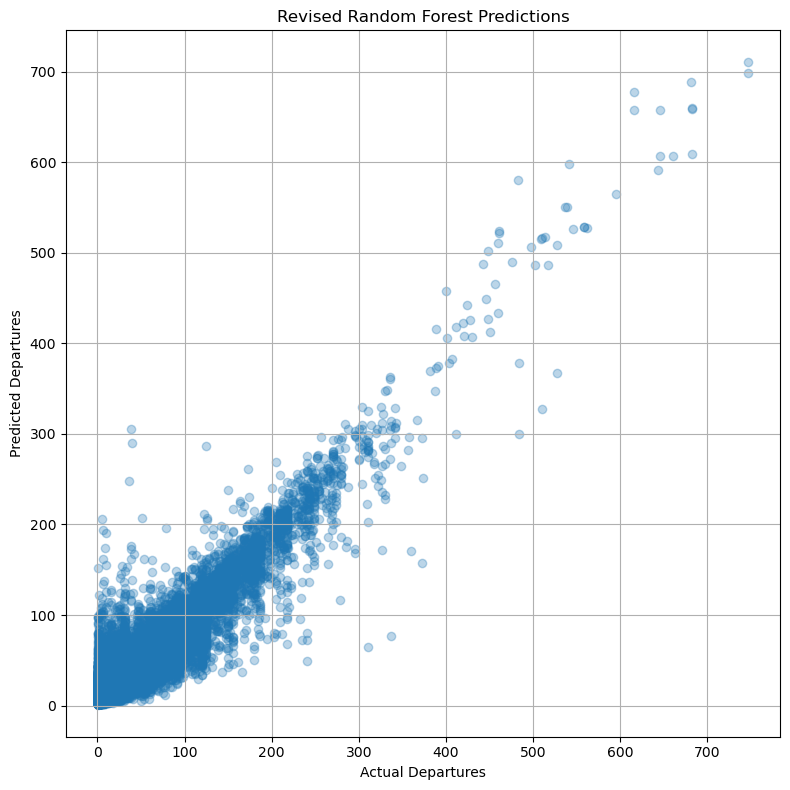

In [35]:
# ============================================================
# Revised Random Forest: Actual vs. Predicted Departures
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test_rev,
    rf_pred_revised,
    alpha=0.3
)

plt.xlabel("Actual Departures")
plt.ylabel("Predicted Departures")

plt.title("Revised Random Forest Predictions")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/figure_12_revised_rf_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

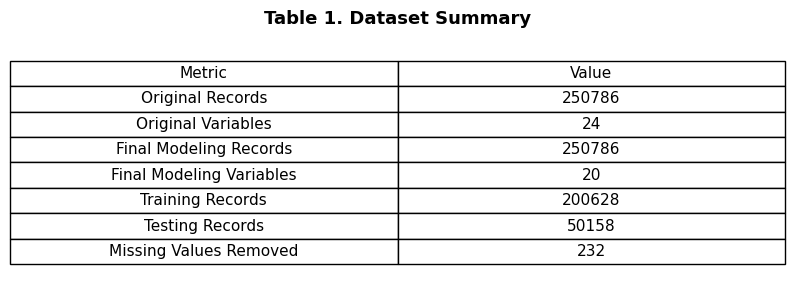

In [36]:
# ============================================================
# Table 1 - Dataset Summary
# ============================================================

table_1_dataset_summary = pd.DataFrame({
    "Metric": [
        "Original Records",
        "Original Variables",
        "Final Modeling Records",
        "Final Modeling Variables",
        "Training Records",
        "Testing Records",
        "Missing Values Removed"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        model_df.shape[0],
        model_df.shape[1],
        X_train.shape[0],
        X_test.shape[0],
        232
    ]
})

fig, ax = plt.subplots(figsize=(8, 3))

ax.axis("off")

table = ax.table(
    cellText=table_1_dataset_summary.values,
    colLabels=table_1_dataset_summary.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title("Table 1. Dataset Summary", fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()

plt.savefig(
    "../figures/table_1_dataset_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

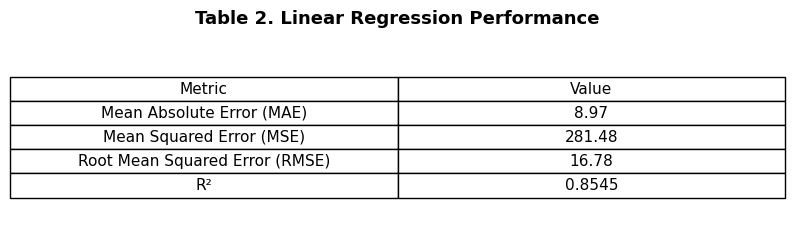

In [37]:
# ============================================================
# Table 2 - Linear Regression Performance
# ============================================================

table_2_linear_regression = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "R²"
    ],
    "Value": [
        round(mae, 2),
        round(mse, 2),
        round(rmse, 2),
        round(r2, 4)
    ]
})

fig, ax = plt.subplots(figsize=(8, 2.5))

ax.axis("off")

table = ax.table(
    cellText=table_2_linear_regression.values,
    colLabels=table_2_linear_regression.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title("Table 2. Linear Regression Performance", fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()

plt.savefig(
    "../figures/table_2_linear_regression_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

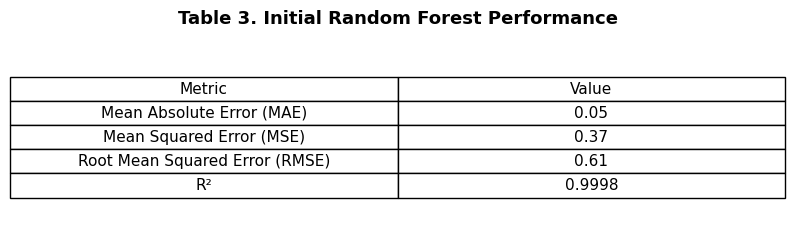

In [39]:
# ============================================================
# Table 3 - Initial Random Forest Performance
# ============================================================

table_3_initial_rf = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "R²"
    ],
    "Value": [
        round(rf_mae, 2),
        round(rf_mse, 2),
        round(rf_rmse, 2),
        round(rf_r2, 4)
    ]
})

fig, ax = plt.subplots(figsize=(8, 2.5))

ax.axis("off")

table = ax.table(
    cellText=table_3_initial_rf.values,
    colLabels=table_3_initial_rf.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title(
    "Table 3. Initial Random Forest Performance",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    "../figures/table_3_initial_random_forest_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

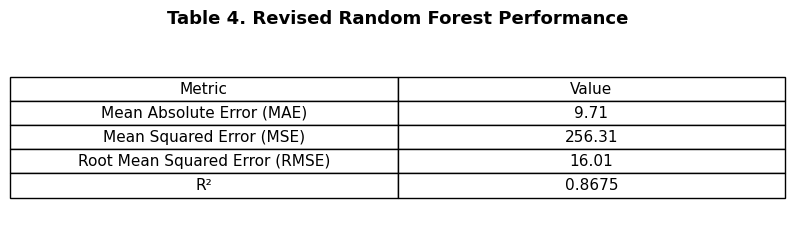

In [40]:
# ============================================================
# Table 4 - Revised Random Forest Performance
# ============================================================

table_4_revised_rf = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "R²"
    ],
    "Value": [
        round(rf_rev_mae, 2),
        round(rf_rev_mse, 2),
        round(rf_rev_rmse, 2),
        round(rf_rev_r2, 4)
    ]
})

fig, ax = plt.subplots(figsize=(8, 2.5))

ax.axis("off")

table = ax.table(
    cellText=table_4_revised_rf.values,
    colLabels=table_4_revised_rf.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title("Table 4. Revised Random Forest Performance", fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()

plt.savefig(
    "../figures/table_4_revised_random_forest_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

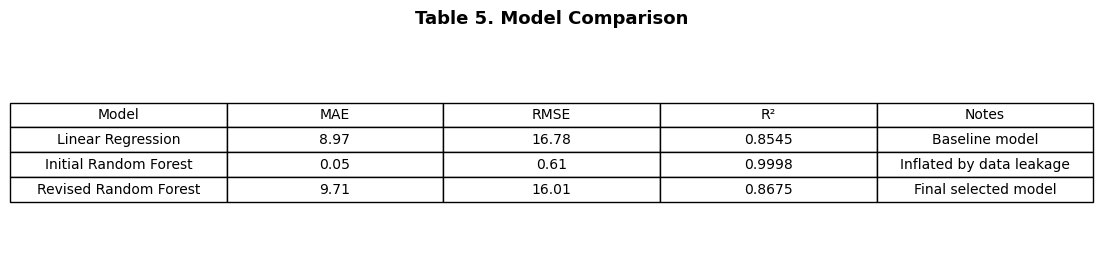

In [41]:
# ============================================================
# Table 5 - Model Comparison
# ============================================================

table_5_model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Initial Random Forest",
        "Revised Random Forest"
    ],
    "MAE": [
        round(mae, 2),
        round(rf_mae, 2),
        round(rf_rev_mae, 2)
    ],
    "RMSE": [
        round(rmse, 2),
        round(rf_rmse, 2),
        round(rf_rev_rmse, 2)
    ],
    "R²": [
        round(r2, 4),
        round(rf_r2, 4),
        round(rf_rev_r2, 4)
    ],
    "Notes": [
        "Baseline model",
        "Inflated by data leakage",
        "Final selected model"
    ]
})

fig, ax = plt.subplots(figsize=(11, 2.8))

ax.axis("off")

table = ax.table(
    cellText=table_5_model_comparison.values,
    colLabels=table_5_model_comparison.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.5)

plt.title("Table 5. Model Comparison", fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()

plt.savefig(
    "../figures/table_5_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

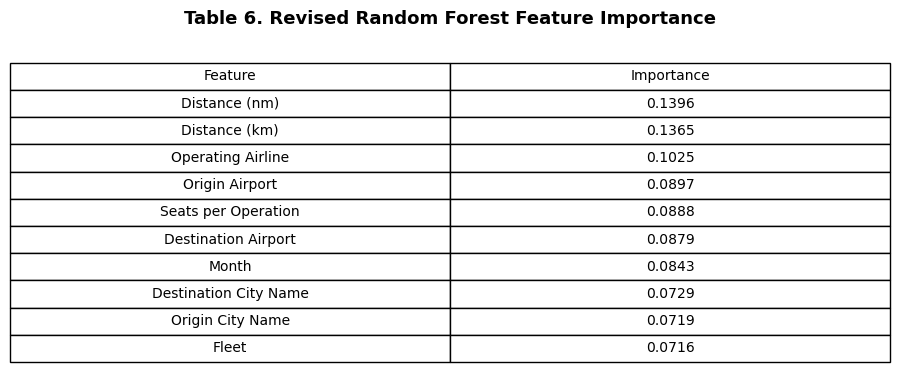

In [42]:
# ============================================================
# Table 6 - Revised Random Forest Feature Importance
# ============================================================

table_6_feature_importance = (
    importance_revised
    .head(10)
    .reset_index()
)

table_6_feature_importance.columns = [
    "Feature",
    "Importance"
]

table_6_feature_importance["Importance"] = table_6_feature_importance["Importance"].round(4)

fig, ax = plt.subplots(figsize=(9, 4))

ax.axis("off")

table = ax.table(
    cellText=table_6_feature_importance.values,
    colLabels=table_6_feature_importance.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.5)

plt.title("Table 6. Revised Random Forest Feature Importance", fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()

plt.savefig(
    "../figures/table_6_revised_rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()